In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("../flight_price.csv")

df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 918.2 KB


,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [8]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [9]:
df["Journey_day"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.day
df["Journey_month"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.month

df.drop(["Date_of_Journey"], axis=1, inplace=True)

In [10]:
df["Dep_hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour
df["Dep_min"] = pd.to_datetime(df["Dep_Time"]).dt.minute

df.drop(["Dep_Time"], axis=1, inplace=True)

In [11]:
df["Arrival_hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour
df["Arrival_min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute

df.drop(["Arrival_Time"], axis=1, inplace=True)

In [12]:
duration = df["Duration"].str.replace("h", " ").str.replace("m", " ")

duration = duration.str.split(expand=True)

df["Duration_hour"] = duration[0].astype(int)
df["Duration_min"] = duration[1].fillna(0).astype(int)

df.drop(["Duration"], axis=1, inplace=True)

In [13]:
df["Total_Stops"] = df["Total_Stops"].map({
    "non-stop":0,
    "1 stop":1,
    "2 stops":2,
    "3 stops":3,
    "4 stops":4
})

In [14]:
df.drop(["Route","Additional_Info"], axis=1, inplace=True)

In [15]:
df.head()

,Airline,Source,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hour,Duration_min
0,IndiGo,Banglore,New Delhi,0,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,13302,1,3,16,50,21,35,4,45


In [16]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [17]:
categorical = ["Airline","Source","Destination"]

ct = ColumnTransformer(
    transformers=[
        ("encoder", OneHotEncoder(drop="first"), categorical)
    ],
    remainder="passthrough"
)

X = ct.fit_transform(X)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [20]:
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [21]:
def evaluate(y_test, y_pred):
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

In [22]:
evaluate(y_test, y_pred_lr)

MAE: 1972.9241585981347
RMSE: 2863.9825869875813
R2 Score: 0.6195911867006523


NameError: name 'y_pred_dt' is not defined

In [24]:
evaluate(y_test, y_pred_rf)

MAE: 1172.7135452715538
RMSE: 2086.7638830278306
R2 Score: 0.7980441457881837


In [25]:
import pickle

pickle.dump(rf, open("flight_price_model.pkl", "wb"))

In [26]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [27]:
evaluate(y_test, y_pred_dt)

MAE: 1317.5200826704104
RMSE: 2403.4764813852803
R2 Score: 0.732089597127201


In [29]:
# ================================
# 1. Import Libraries
# ================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle
import warnings
warnings.filterwarnings("ignore")


# ================================
# 2. Load Dataset
# ================================

df = pd.read_csv("../flight_price.csv")

print("Dataset Shape:", df.shape)
print(df.head())


# ================================
# 3. Data Cleaning
# ================================

df.dropna(inplace=True)

# ================================
# 4. Feature Engineering
# ================================

# Extract Journey Day and Month
df["Journey_day"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.day
df["Journey_month"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.month

df.drop(["Date_of_Journey"], axis=1, inplace=True)


# Extract Departure Time
df["Dep_hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour
df["Dep_min"] = pd.to_datetime(df["Dep_Time"]).dt.minute

df.drop(["Dep_Time"], axis=1, inplace=True)


# Extract Arrival Time
df["Arrival_hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour
df["Arrival_min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute

df.drop(["Arrival_Time"], axis=1, inplace=True)


# Convert Duration

duration = df["Duration"].str.replace("h"," ").str.replace("m"," ")

duration = duration.str.split(expand=True)

df["Duration_hour"] = duration[0].astype(int)
df["Duration_min"] = duration[1].fillna(0).astype(int)

df.drop(["Duration"], axis=1, inplace=True)


# Convert Stops to Numeric
df["Total_Stops"] = df["Total_Stops"].map({
    "non-stop":0,
    "1 stop":1,
    "2 stops":2,
    "3 stops":3,
    "4 stops":4
})


# Drop unnecessary columns
df.drop(["Route","Additional_Info"], axis=1, inplace=True)


# ================================
# 5. Define Features and Target
# ================================

X = df.drop("Price", axis=1)
y = df["Price"]


# ================================
# 6. Encode Categorical Features
# ================================

categorical_cols = ["Airline","Source","Destination"]

ct = ColumnTransformer(
    transformers=[
        ("encoder", OneHotEncoder(drop="first"), categorical_cols)
    ],
    remainder="passthrough"
)

X = ct.fit_transform(X)


# ================================
# 7. Train Test Split
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ================================
# 8. Train Models
# ================================

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


# Decision Tree
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)


# Random Forest
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


# ================================
# 9. Model Evaluation Function
# ================================

def evaluate_model(y_test, y_pred, model_name):
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("Model:", model_name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("------------------------")


# Evaluate Models
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")


# ================================
# 10. Save Best Model
# ================================

pickle.dump(rf, open("flight_price_model.pkl","wb"))

print("Model saved successfully!")

Dataset Shape: (10683, 11)
       Airline Date_of_Journey    Source Destination                  Route  \
0       IndiGo      24/03/2019  Banglore   New Delhi              BLR → DEL   
1    Air India       1/05/2019   Kolkata    Banglore  CCU → IXR → BBI → BLR   
2  Jet Airways       9/06/2019     Delhi      Cochin  DEL → LKO → BOM → COK   
3       IndiGo      12/05/2019   Kolkata    Banglore        CCU → NAG → BLR   
4       IndiGo      01/03/2019  Banglore   New Delhi        BLR → NAG → DEL   

  Dep_Time  Arrival_Time Duration Total_Stops Additional_Info  Price  
0    22:20  01:10 22 Mar   2h 50m    non-stop         No info   3897  
1    05:50         13:15   7h 25m     2 stops         No info   7662  
2    09:25  04:25 10 Jun      19h     2 stops         No info  13882  
3    18:05         23:30   5h 25m      1 stop         No info   6218  
4    16:50         21:35   4h 45m      1 stop         No info  13302  
Model: Linear Regression
MAE: 1972.9241585981347
RMSE: 2863.982586987581

In [30]:
print("Train R2:", rf.score(X_train, y_train))
print("Test R2:", rf.score(X_test, y_test))

Train R2: 0.9536980015772379
Test R2: 0.7967805516923243


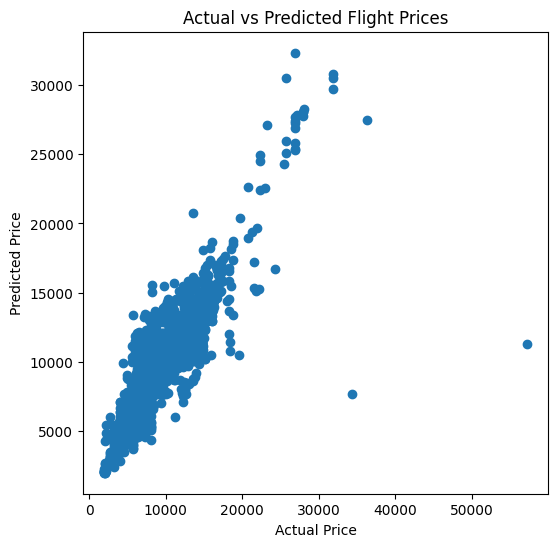

In [34]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices")
plt.show()

In [35]:
importances = rf.feature_importances_

for i, val in enumerate(importances):
    print(i, val)

0 0.005929327824213954
1 0.001122295163028857
2 0.0072872760565206645
3 0.06269326869915802
4 0.06148828396886248
5 0.020741593404719046
6 0.0009405120816912745
7 0.0026352908479350015
8 8.512526145830057e-06
9 0.0032684258582700585
10 5.1735004522248094e-05
11 0.0006644246020671714
12 0.0029512502047736484
13 0.004488120587008981
14 0.0031404474334356548
15 0.0028852743192291086
16 0.00023041719918123234
17 0.004010341894753053
18 0.0004877402232296599
19 0.01691031805487155
20 0.033817855202817264
21 0.1292307490023909
22 0.061991715004728935
23 0.029893091436758203
24 0.022573065812252015
25 0.035272748992690825
26 0.02097141485020011
27 0.4437937936455685
28 0.020520710098975648


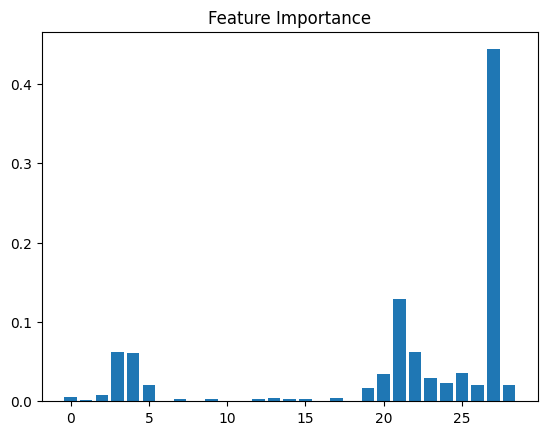

In [33]:
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()

In [36]:
feature_names = ct.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

                                              Feature  Importance
27                           remainder__Duration_hour    0.443794
21                             remainder__Journey_day    0.129231
3                        encoder__Airline_Jet Airways    0.062693
22                           remainder__Journey_month    0.061992
4               encoder__Airline_Jet Airways Business    0.061488
25                            remainder__Arrival_hour    0.035273
20                             remainder__Total_Stops    0.033818
23                                remainder__Dep_hour    0.029893
24                                 remainder__Dep_min    0.022573
26                             remainder__Arrival_min    0.020971
5                  encoder__Airline_Multiple carriers    0.020742
28                            remainder__Duration_min    0.020521
19                     encoder__Destination_New Delhi    0.016910
2                             encoder__Airline_IndiGo    0.007287
0         

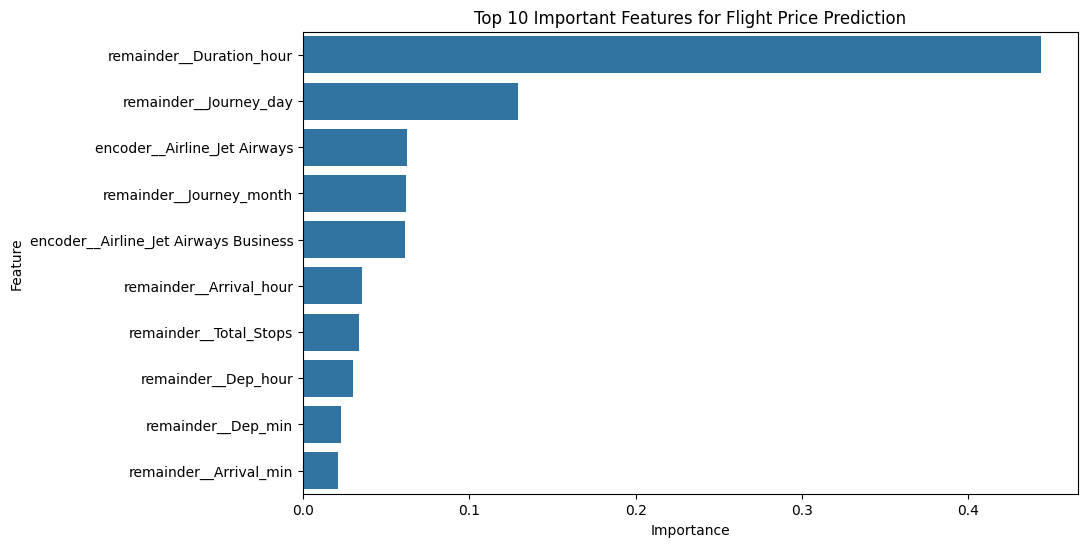

In [37]:
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(10)
)

plt.title("Top 10 Important Features for Flight Price Prediction")
plt.show()

In [38]:
import pickle

# save model
pickle.dump(rf, open("flight_price_model.pkl", "wb"))

# save encoder
pickle.dump(ct, open("encoder.pkl", "wb"))

print("Model and encoder saved successfully")

Model and encoder saved successfully


In [39]:
# ===============================
# Load saved model and encoder
# ===============================

import pickle
import numpy as np

model = pickle.load(open("flight_price_model.pkl", "rb"))
encoder = pickle.load(open("encoder.pkl", "rb"))

In [40]:
# ===============================
# Create sample flight input
# ===============================

sample_data = pd.DataFrame({
    "Airline": ["IndiGo"],
    "Source": ["Delhi"],
    "Destination": ["Cochin"],
    "Total_Stops": [1],
    "Journey_day": [15],
    "Journey_month": [3],
    "Dep_hour": [10],
    "Dep_min": [30],
    "Arrival_hour": [13],
    "Arrival_min": [20],
    "Duration_hour": [2],
    "Duration_min": [50]
})

In [41]:
sample_encoded = encoder.transform(sample_data)

In [42]:
prediction = model.predict(sample_encoded)

print("Predicted Flight Price:", prediction[0])

Predicted Flight Price: 4716.636666666666


In [43]:
def predict_flight_price(
    airline,
    source,
    destination,
    stops,
    journey_day,
    journey_month,
    dep_hour,
    dep_min,
    arrival_hour,
    arrival_min,
    duration_hour,
    duration_min
):

    input_df = pd.DataFrame({
        "Airline":[airline],
        "Source":[source],
        "Destination":[destination],
        "Total_Stops":[stops],
        "Journey_day":[journey_day],
        "Journey_month":[journey_month],
        "Dep_hour":[dep_hour],
        "Dep_min":[dep_min],
        "Arrival_hour":[arrival_hour],
        "Arrival_min":[arrival_min],
        "Duration_hour":[duration_hour],
        "Duration_min":[duration_min]
    })

    encoded = encoder.transform(input_df)

    prediction = model.predict(encoded)

    return prediction[0]

In [44]:
price = predict_flight_price(
    "IndiGo",
    "Delhi",
    "Cochin",
    1,
    15,
    3,
    10,
    30,
    13,
    20,
    2,
    50
)

print("Predicted Price:", price)

Predicted Price: 4716.636666666666
